# Numerical Elliptic BVP Analysis

## The Continuous Problem
The first and simplest problem is an elliptic BVP of the form, $$-u''(x) = f(x), \quad \text{for} \ x \in (0,1)$$ 
Where $u:(0,1) \rightarrow \mathbb{R}$ subject to the Dirichlet boundary conditions (DBCs): 
$$u(0) = \alpha \\
u(1) = \beta$$
with $f:(0,1) \rightarrow \mathbb{R}, \alpha \in \mathbb{R}$, and $\beta \in \mathbb{R}$.

## Environment Setup

In [10]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np 
import matplotlib.pyplot as plt 
from src.solvers.elliptic import elliptic_bvp_solver
from src.utils.convergence import plot_convergence

## Numerical Analysis 
To derive the used central difference approximation, we assume that there is a linear relationship between 3 points in a central difference pattern for some coefficients $c_{-1}, c_0, c_1$ such that
$$u''(x) = c_{-1} u(x-h) + c_0 u(x) + c_1 u(x+h) + E(h) \qquad (1)$$

To find our coefficients, we use the Taylor series for $u(x-h)$, and $u(x+h)$ with respect to $u(x)$,
$$u(x-h) = u(x) - h u'(x) + \frac{h^2}{2} u''(x) - \frac{h^3}{6} u^{(3)}(x) + \frac{h^4}{24} u^{(4)}(x) + O(h^5)$$

$$u(x+h) = u(x) + h u'(x) + \frac{h^2}{2} u''(x) + \frac{h^3}{6} u^{(3)}(x) + \frac{h^4}{24} u^{(4)}(x) + O(h^5)$$

Plugging these into $(1)$ gives
$$u''(x) - E(h) = (c_{-1} + c_0 + c_1) u(x) + h (c_{1} - c_{-1}) u'(x) + \frac{h^2}{2} (c_{-1} + c_1) u''(x) + \frac{h^3}{6} (c_1 - c_{-1}) u^{(3)}(x) + \frac{h^4}{24} (c_{-1} + c_1) u^{(4)}(x) + O(h^5)$$

To maintain $O(h^2)$ convergence, we choose $c_{-1}$, $c_0$, $c_1$ such that
$$c_{-1} + c_0 + c_1 = 0 \\
c_1 - c_{-1} = 0$$
$\qquad$ and
$$\frac{h^2}{2} (c_{-1} + c_1) = 1$$

Solving the system of equations produces:
$$ c_1 = c_{-1} = \frac{1}{h^2},\quad c_0 = -\frac{2}{h^2}$$

Plugging these back into the linear relation assumption,
$$\frac{u(x - h) - 2u(x) + u(x + h)}{h^2} = u''(x) + \frac{h^2}{12} u^{(4)}(x) + O(h^4)$$

*Note: Odd exponents cancel due to the symmetry in the Taylor expansions, hence the $O(h^4)$ term.*

Where epsilon in our original equation must be
$$E(h) = -\frac{h^2}{12} u^{(4)}(x) + O(h^4) = O(h^2)$$

Therefore, our final approximation reads as
$$u''(x) = \frac{u(x - h) - 2u(x) + u(x + h)}{h^2} + O(h^2)$$

## Implementation and Convergence Analysis
### Discretisation
To turn the above approximation into a solvable system on a computer, we write it as 
$$u''(x_i) \approx \frac{u_{i-1} - 2u_i + u_{i+1}}{h^2}$$

Where $u_i$ is the numerical approximation of the analytic solution $u(x_i)$ at $x_i = x_0 + ih,$ and $h = \Delta x$. 

Now plugging this into the original problem, $-u''(x) = f(x)$, we get
$$-\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2} = f(x_i)$$

Rearranging this, we get 
$$-u_{i-1} + 2u_i - u_{i+1} = h^2 f(x_i)$$ 

*Note: Our BVP gives sets $u_0$ and $u_N$ so we only solve for $u_i$ where $i = 1, ... N-1$ on a grid of $N+1$ nodes with $N$ steps of size $h$.* 

It follows that this can be turned into a tridiagonal system of the form $Au = b$ on the internal points of the grid where, 

$$A = \begin{bmatrix} 
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \cdots & 0 \\
0 & -1 & 2 & \ddots & \vdots \\
\vdots & \vdots & \ddots & \ddots & -1 \\
0 & 0 & \cdots & -1 & 2
\end{bmatrix}, 
\ u = \begin{bmatrix} u_1 \\
u_2 \\
\vdots \\
u_{N-2} \\
u_{N-1}
\end{bmatrix}$$

To implement the boundary conditions $u_0 = u(0) = \alpha$, $u_N = u(N) = \beta$, we plug them into the approximations at $1$ and $N-1$:
$$-\frac{u_{0} - 2u_1 + u_{2}}{h^2} = f(x_1) \quad \implies \quad -u_{0} + 2u_1 - u_{2} = h^2 f(x_1) \quad \implies \quad 2u_1 - u_{2} = h^2 f(x_1) + u_{0} = h^2 f(x_1) + \alpha$$

Similarly, 
$$-u_{N-2} + 2u_{N-1} - u_{N} = h^2 f(x_{N-1}) \quad \implies \quad -u_{N-2} + 2u_{N-1}= h^2 f(x_{N-1}) + u_{N} = h^2 f(x_{N-1}) + \beta$$

In our linear system of the form $Au = b$, we construct our right hand side (RHS) vector $b$ by combining the scaled source function $h^2 f(x)$ with the boundary conditions,
$$\begin{bmatrix}
h^2 f(x_1) + \alpha \\
h^2 f(x_2) \\
\vdots \\
h^2 f(x_{N-2}) \\
h^2 f(x_{N-1}) + \beta
\end{bmatrix}$$

Now that we have a tridiagonal, symmetric positive definite (SPD) matrix $A$, the vector $u$ we are solving for, and our RHS vector $b$, we can apply a standard Thomas algorithm without pivoting to solve the system in $O(N)$ time (rather than $O(N^3)$ with a standard LU factorisation). This is written in `tridiagonal.py` under the `thomas_solver()` function.

The plot below shows the numerical approximation plotted against the analytic solution.

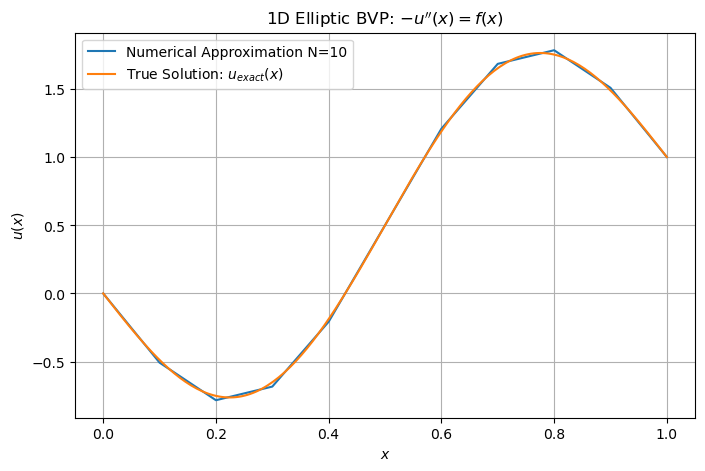

In [8]:
alpha = 0
beta = 1
u_exact = lambda x: x - np.sin(2*np.pi*x)
f = lambda x: -4*(np.pi**2)*np.sin(2*np.pi*x)
N = 10
x, u = elliptic_bvp_solver(alpha, beta, f, N)
        
#Plot against true solution
plt.figure(figsize=(8,5))  
plt.plot(x, u, '-', label=f'Numerical Approximation N={N}')

x_fine = np.linspace(0.0, 1.0, 200)
plt.plot(x_fine, u_exact(x_fine), label='True Solution: $u_{exact}(x)$')

plt.title("1D Elliptic BVP: $-u''(x) = f(x)$")
plt.xlabel("$x$")
plt.ylabel("$u(x)$")
plt.legend()   
plt.grid(True)
plt.show()

### Proof of Convergence
As stated above, the central difference method (CDM) has a local truncation error (LTE) $O(h^2)$. To prove the global error (GE) of $O(h^2)$, we must look at the Fundamental Convergence Theorem. The Fundamental Convergence Theorem states that $O(h^p)$ LTE + stability $\implies O(h^p)$ global error.

We have shown $O(h^2)$ LTE above, and to prove stability, we must show that the tridiagonal matrix $A^h$ satisfies the condition $\| (A^h)^{-1} \|_2 \le C,$ for some $C < \infty.$ 

Since $A^h$ is SPD, the 2-norm of its inverse is equal to its spectral radius, which is governed by the smallest eigenvalue of $A^h$,
$$\| (A^h)^{-1} \|_2 = \frac{1}{\lambda_{\min}(A^h)} \le C$$

Using the standard CDM tridiagonal matrix eigenvalues, and considering the negation of our function $u$, we have that 
$$\lambda_p = \frac{2}{h^2} (1- \cos(p \pi h)).$$

Applying the standard double angle formula $1 - \cos(\theta) = 2 \sin^2(\theta / 2)$, we get,
$$\lambda_p = \frac{4}{h^2} \sin^2 \biggl(\frac{p \pi h}{2} \biggr), \quad \text{for} \ p = 1, 2, 3, ..., N-1$$

It intuitively follows that $\lambda_{\min}$ occurs at $p=1$:
$$\lambda_{\min} = \frac{4}{h^2} \sin^2 \biggl(\frac{\pi h}{2} \biggr)$$

Taking the Taylor series of $\sin(\pi h / 2)$ gives,
$$\lambda_{\min} = \frac{4}{h^2} \biggl( \frac{\pi h}{2} + O(h^3) \biggr)^2 = \frac{4}{h^2} \biggl( \frac{\pi^2 h^2}{4} + O(h^4) \biggr) = \pi^2 + O(h^2)$$

As $h \rightarrow 0$, we get that $\lambda_{\min} \approx \pi^2$. Therefore, $\| (A^h)^{-1} \|_2 \le 1/\pi^2 = C$

As such, we can say that the CDM scheme has a $O(h^2)$ global error by the Fundamental Convergence Theorem. 

### Log-log Plots
The error of a scheme scales with grid spacing $h$ as $E = Ch^p$ for some $C > 0$. $\\$
To turn this into a comparable metric, a linear relation can be found by taking logs of both sides to get an equation of the form $y = Mx + c$:
$$\log (E) = \log (C h^p) = p\log(h) + \log (C)$$

This gives a log-log relation which we can display as a straight line on an appropriate plot with the order of convergence represented by the slope. As implied above by the $O(h^2)$ error of the central difference approximation, the plot should show a gradient of 2. 

To plot this, we use the below wrapper with adjustable variables, source function, and boundary conditions. The plotting script is under `convergence.py` and plots against the array of `N_values`, preset at 10, 20, 40, 80, and 160.

The slope of our log relation is 1.99, proving 1.991895580202635 convergence.


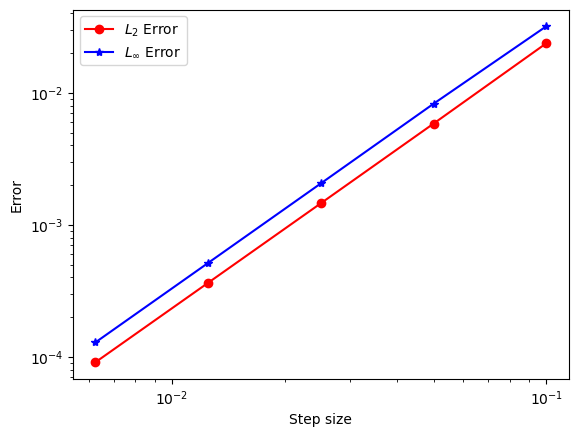

(np.float64(1.991895580202635),
 array([0.1    , 0.05   , 0.025  , 0.0125 , 0.00625]),
 array([0.03191593, 0.00826542, 0.00205871, 0.0005142 , 0.00012852]))

In [9]:
def elliptic_wrapper(N):
    #Defining our step size
    dx = 1.0/N

    #Assigning parameters
    alpha = 0
    beta = 1
    f = lambda x: -4*(np.pi**2)*np.sin(2*np.pi*x)

    #Asigning our exact and numerical solution
    x, u_num = elliptic_bvp_solver(alpha, beta, f, N)
    u_exact = x - np.sin(2*np.pi*x)

    #Finding Error
    L_inf_error = np.max(np.abs(u_num - u_exact))
    L2_error = np.sqrt(dx*np.sum((u_num - u_exact)**2))
    
    return dx, L2_error, L_inf_error

N_values = [10, 20, 40, 80, 160]

plot_convergence(elliptic_wrapper, N_values)

## Discussion
The log-log plots section claims that the second order spatial convergence is intuitive and follows directly from the above derivations. The plot above proves this claim with the calculated gradient of $p = 1.99... \approx 2$, calculated with the $L_\infty$ error. As such, the claim of second order convergence holds true under practice, governed only by the spatial grid sizing. 

While this is unconditionally true on paper, computers do not have perfect numerical resolution. This leads to round off error and floating point inaccuracies which typically happen around an $N$ of $10^5$ to $10^7$, which is identical to a step size, $h$, of $10^{-5}$ to $10^{-7}$. This can be seen visually by altering the `N_values` array and adding a large step count $N$.

This failure at high $N$ occurs due to the inherent nature of solving the system $A^h u = b$. To solve this, even if not explicitly, we must invert the matrix $A^h$ with scaling factor $\frac{1}{h^2}$ ($u = (A^h)^{-1}b$). As $h \to 0$, the condition number, $\kappa (A^h) = \frac{\lambda_{\max}}{\lambda_{\min}}$ grows with $O(h^{-2}) = O(N^2)$. At $N = 10^6$, the conditioning number reaches $\kappa(A^h) \approx 10^{12}$. When solving the system of equations, the floating point rounding error is amplified by this high condition number, causing the floating point rounding error to take over the $O(h^2)$ truncation error.

While the $L_2$ error ($2$-norm) and $L_{\infty}$ error ($\infty$-norm) are ultimately showing the same thing, the differences change how the error is displayed and how it reacts when the round off error starts to compound. $L_\infty$, defined as $\max|u_{\text{num}} - u_{\text{exact}}|$, tracks the worst case error, which means it sits higher than the $L_2$ error, which is an average error across the entire grid, defined as $\sqrt{h \sum_i e_i^2}$. It follows that the $L_\infty$ error plot would react and diverge quicker than the $L_2$ error. 

## Summary
To summarise the notebook, we have derived the second order central difference approximation function via Taylor series, discretised the elliptic BVP problem, proven convergence using the Fundamental Convergence Theorem, proved the convergence in practice using log-log plots, and discussed limitations and outcomes of the scheme. 